This script takes the all_data.pkl and saves: <br>
-a cropped image stack (.npy file), recombining after looking at each image size separately <br>
-a background image <br>
-a VCC image <br>

This script reorders some of the data, as it will be chunked by image size.  The all_data DF will also be ordered this way, so it is valid.


## User Input
Choose which dataset to work on

In [ ]:
%run -i ../src/General_Data/Analysis/Data_Classes.py
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2024_241.return_params()

# # pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = March_2024_241.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_571.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = April_2024_241.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = June_2024_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = October_2024_571.return_params()

pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_241.return_params()
pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = January_2025_571.return_params()

# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_571.return_params()
# pathlist,screen,save_loc,empty,prefixes,DAQ_Matching,bg_file,raw_vcc = test_241.return_params()


## Import Statements

In [64]:
import numpy as np
import pandas as pd
import os
import glob
import copy
from Image_Analysis import *

## Manipulate Inputs

In [65]:
screen_nickname = screen.split(':')[2]
os.makedirs(save_loc, exist_ok=True)

## Load data

In [66]:
all_data = pd.read_pickle(save_loc + "All_Data_" + screen_nickname + '.pkl')

## Remove blank image slots

In [67]:
df_sizes = all_data[[screen.split('Image:')[0] + 'Image:ArraySize1_RBV',screen.split('Image:')[0] + 'Image:ArraySize0_RBV']]
df_sizes.drop_duplicates(inplace=True)

idx = []
for i,row in df_sizes.iterrows():
    test = 0
    try:
        (int(row[screen.split('Image:')[0] + 'Image:ArraySize0_RBV']))
    except:
        test = test +1
    try:
        (int(row[screen.split('Image:')[0] + 'Image:ArraySize1_RBV']))
    except:test = test+1
    idx.append(test)
    
df_sizes 
idx=np.array(idx)
idx = idx>1
idx

df_sizes = df_sizes.loc[~idx]

/tmp/ipykernel_2185394/3337909852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sizes.drop_duplicates(inplace=True)


In [68]:
np.sum(np.isnan((all_data['QUAD:IN10:525:BCTRL'].astype(float))))

np.int64(0)

In [70]:
list(all_data.columns)

['SOLN:IN10:121:BACT',
 'SOLN:IN10:111:BACT',
 'QUAD:IN10:121:BACT',
 'QUAD:IN10:122:BACT',
 'QUAD:IN10:361:BACT',
 'QUAD:IN10:371:BACT',
 'QUAD:IN10:425:BACT',
 'QUAD:IN10:441:BACT',
 'QUAD:IN10:511:BACT',
 'QUAD:IN10:525:BACT',
 'SOLN:IN10:121:BCTRL',
 'SOLN:IN10:111:BCTRL',
 'QUAD:IN10:121:BCTRL',
 'QUAD:IN10:122:BCTRL',
 'QUAD:IN10:361:BCTRL',
 'QUAD:IN10:371:BCTRL',
 'QUAD:IN10:425:BCTRL',
 'QUAD:IN10:441:BCTRL',
 'QUAD:IN10:511:BCTRL',
 'QUAD:IN10:525:BCTRL',
 'KLYS:LI10:21:PDES',
 'KLYS:LI10:21:ADES',
 'KLYS:LI10:21:AMPL',
 'KLYS:LI10:21:PHAS',
 'KLYS:LI10:21:SFB_PDIS',
 'KLYS:LI10:31:PDES',
 'KLYS:LI10:31:ADES',
 'KLYS:LI10:31:AMPL',
 'KLYS:LI10:31:PHAS',
 'KLYS:LI10:41:PDES',
 'KLYS:LI10:41:ADES',
 'KLYS:LI10:41:AMPL',
 'KLYS:LI10:41:PHAS',
 'KLYS:LI10:51:PHAS',
 'LASR:LT10:930:PWR',
 'PMTR:HT10:950:PWR',
 'IOC:SYS1:MP01:LSHUTCTL',
 'BPMS:IN10:221:X',
 'BPMS:IN10:371:X',
 'BPMS:IN10:425:X',
 'BPMS:IN10:511:X',
 'BPMS:IN10:525:X',
 'BPMS:IN10:581:X',
 'BPMS:IN10:631:X',
 'BPMS:

In [71]:
df_sizes

,PROF:IN10:571:Image:ArraySize1_RBV,PROF:IN10:571:Image:ArraySize0_RBV
0,1038,1388
4027,702,854


## Make Image Stacks

In [72]:
def im_stack_from_df(df,col,ncolcol,nrowcol,fliplr=0,rot=0):
    ncols=df[ncolcol]
    nrows=df[nrowcol]
    if np.abs(np.sum(np.diff(ncols)))+np.abs(np.sum(np.diff(nrows)))==0:
        ncol=int(ncols.mean())
        nrow=int(nrows.mean())
        imgs=df[col]
        if rot:
            imgArray=np.zeros([len(imgs),nrow,ncol])
        else:
            imgArray=np.zeros([len(imgs),ncol,nrow])
        j=0
        
        for i,row in df.iterrows():
            # print(i)
            # print(j)
            img=imgs.iloc[j]
            # plt.imshow(img)
            
            img=np.reshape(img,(ncol,nrow))
            if rot:
                img=scipy.ndimage.rotate(img,90)
            if fliplr:
                img=np.fliplr(img)
            imgArray[j,:,:]=img
            j=j+1
    return imgArray

## Make different image stacks
Technically a list of image stacks, one for each image size

In [73]:
imgArray_List = []
df_list = []
for i, row in df_sizes.iterrows():
    idx1 = all_data[screen.split('Image:')[0] + 'Image:ArraySize1_RBV']==row[screen.split('Image:')[0] + 'Image:ArraySize1_RBV']
    idx2 = all_data[screen.split('Image:')[0] + 'Image:ArraySize0_RBV']==row[screen.split('Image:')[0] + 'Image:ArraySize0_RBV']
    idx = idx1*idx2
    df_subset = all_data.loc[idx]
    df_list.append(df_subset)
    imgArray=im_stack_from_df(df_subset,screen,screen.split('Image:')[0] + 'Image:ArraySize1_RBV',screen.split('Image:')[0] + 'Image:ArraySize0_RBV',fliplr=0,rot=0)
    imgArray_List.append(imgArray)

## Show images sums of images so that I can crop(p) to an ROI 
on each of the unique sizes


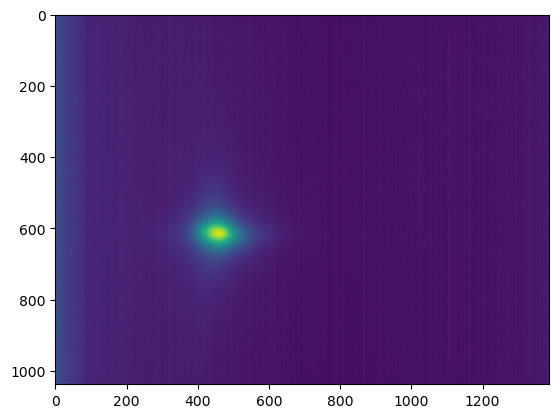

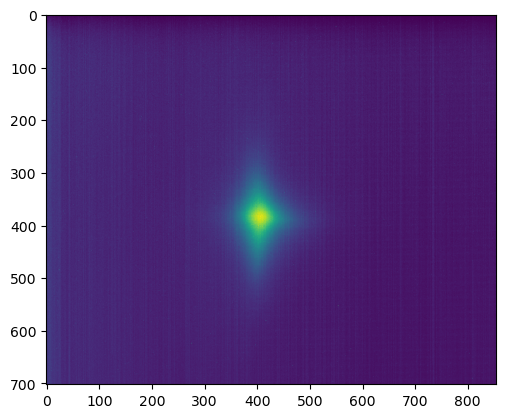

In [74]:
for i in range(len(imgArray_List)):
    img_temp = np.sum(imgArray_List[i],0)
    plt.figure()
    plt.imshow(np.sum(imgArray_List[i],0))
    plt.show()


    
    
    

# USER INPUT HERE Crop images

In [86]:
# bound_list = [{'xstart': 600,'xend': 900,'ystart': 300, 'yend': 600}] # June
bound_list = [{'xstart': 200,'xend': 700,'ystart': 100, 'yend': 600},
              {'xstart': 400,'xend': 900,'ystart': 198, 'yend': 698},
              {'xstart': 700,'xend': 1200,'ystart': 400, 'yend': 900}] #January
# bound_list = [{'xstart': 800,'xend': 1100,'ystart': 500, 'yend': 800}] # April
# bound_list = [{'xstart': 800,'xend': 1100,'ystart': 450, 'yend': 750},
#               {'xstart': 50,'xend': 350,'ystart': 450, 'yend': 750}] #October
bound_list = [{'xstart': 725,'xend': 1025,'ystart': 325, 'yend': 625}] # Jan 241
bound_list = [{'xstart': 385,'xend': 685,'ystart': 325, 'yend': 625}] # Mar 241
# bound_list = [{'xstart': 700,'xend': 1000,'ystart': 325, 'yend': 625}] # Apr 241
# bound_list = [{'xstart': 250,'xend': 550,'ystart': 175, 'yend': 475}] # Jan 2025 241
# bound_list = [{'xstart': 700,'xend': 1100,'ystart': 400, 'yend': 800},
#               {'xstart': 250,'xend': 650,'ystart': 200, 'yend': 600}] #October
# bound_list = [{'xstart': 725,'xend': 1125,'ystart': 400, 'yend': 800},
#               {'xstart': 250,'xend': 650,'ystart': 200, 'yend': 600}] #Jan 2025 571
# bound_list = [{'xstart': 750,'xend': 1150,'ystart': 450, 'yend': 850}] # March 571
# bound_list = [{'xstart': 0,'xend': -1,'ystart': 0, 'yend': -1}] #Test

# bound_list = [{'xstart': 100,'xend': 600,'ystart': 100, 'yend': 600},
#               {'xstart': 0,'xend': 500,'ystart': 198, 'yend': 698},
#               {'xstart': 100,'xend': 600,'ystart': 400, 'yend': 900}] #January 2024 571 new
# bound_list = [{'xstart': 213,'xend': 813,'ystart': 175, 'yend': 775}] # Jan 241 new
# bound_list = [{'xstart': 200,'xend': 600,'ystart': 450, 'yend': 850}] # March 571
bound_list = [{'xstart': 275,'xend': 575,'ystart': 500, 'yend': 800}] # April 571

bound_list = [{'xstart': 350,'xend': 750,'ystart': 250, 'yend': 650}] # April 241

# bound_list = [{'xstart': 175,'xend': 475,'ystart': 350, 'yend': 650}] # June 571

# bound_list = [{'xstart': 300,'xend': 600,'ystart': 450, 'yend': 750},
#               {'xstart': 100,'xend': 400,'ystart': 450, 'yend': 750}] #October
bound_list = [{'xstart': 150,'xend': 450,'ystart': 175, 'yend': 475}] # Jan 2025 241

bound_list = [{'xstart': 250,'xend': 650,'ystart': 400, 'yend': 800},
              {'xstart': 200,'xend': 600,'ystart': 200, 'yend': 600}] #Jan 2025 571

# bound_list = [{'xstart': 275,'xend': 575,'ystart': 450, 'yend': 750},
#               {'xstart': 115,'xend': 415,'ystart': 450, 'yend': 750}] #October

image_stack = []
for i in range(len(bound_list)):
    imArray = imgArray_List[i]
    test = imArray[:,bound_list[i]['ystart']:bound_list[i]['yend'],bound_list[i]['xstart']:bound_list[i]['xend']]
    image_stack.append(test)

## Get Gaussian centroids for each image size
Important for aligning the proper background images

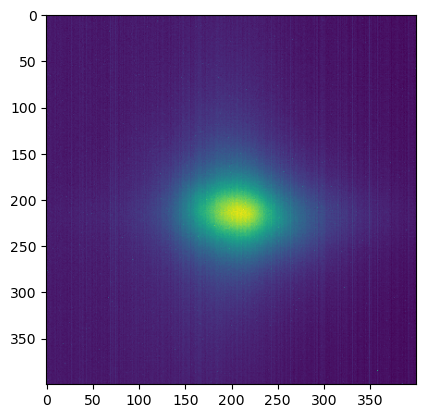

<Figure size 640x480 with 0 Axes>

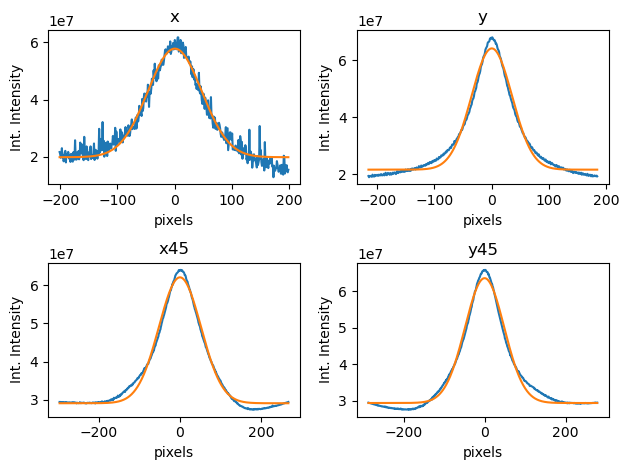

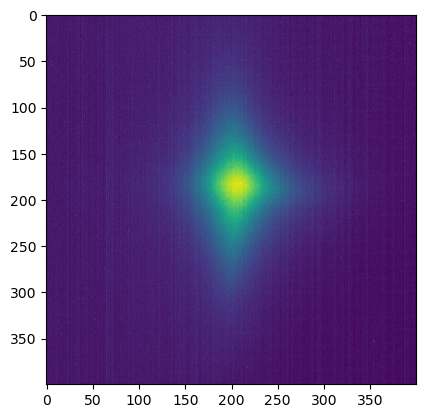

<Figure size 640x480 with 0 Axes>

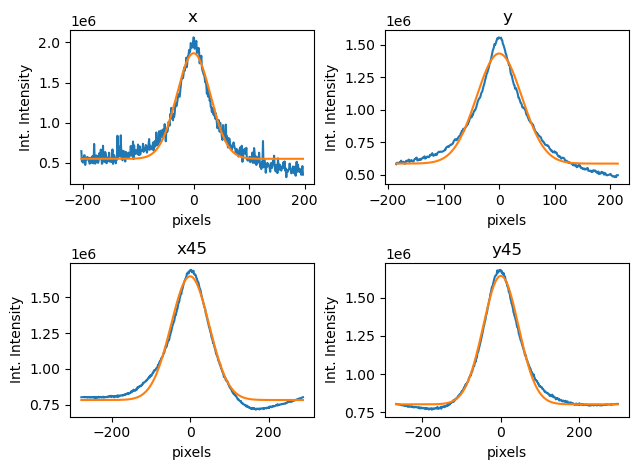

In [87]:
xcs = []
ycs = []

for i in range(len(imgArray_List)):
    img_temp = np.sum(image_stack[i],0)
    plt.figure()
    plt.imshow(img_temp)
    # plt.clim(0,5000)
    plt.show() 
    xfit,yfit,xfit45,yfit45 = Gaussian_Fit_4_Dim(img_temp)
    visualize_projections(img_temp)
    xcs.append(xfit.Center)
    ycs.append(yfit.Center)
    

## Load background image

In [88]:
if bg_file is not None:
    bg_files = glob.glob(bg_file)
    if len(bg_files)<1:
        bg_file = None
    else: 
        bg_arr = []
        for bg in bg_files:
            bg_img = np.load(bg,allow_pickle=True)
            bg_img = np.reshape(bg_img.item()[screen],(bg_img.item()[screen.split('Image:')[0] + 'Image:ArraySize1_RBV'],bg_img.item()[screen.split('Image:')[0] + 'Image:ArraySize0_RBV']))
            bg_arr.append(bg_img)


        bg_img = np.mean(np.array(bg_arr),0)
    
    

## Find background images by image sum
1) combine the images into a giant stack
2) Plot to make sure image makes sense
3) Find image sum for each and plot
4) Threshold, find indicies of low background images
5) Look at possible background images
6) Select background image(s)

In [89]:
bg_file

'/global/cfs/cdirs/m4272/cropp/2025-01-19/*background*'

In [90]:
if bg_file is None:
    big_img_arr = np.concatenate(image_stack,axis=0)


    plt.imshow(np.mean(big_img_arr,0))
    plt.colorbar()

### Make and plot sums

In [91]:
if bg_file is None:
    sum_sum = np.sum(big_img_arr,2)
    sum_sum = np.sum(sum_sum,1)
    plt.plot(sum_sum)

### Threshold and select indices of possible background images

In [92]:
if bg_file is None:
    test = sum_sum<0.2e6
    np.sum(test)

### Look at background candidate images

In [93]:
if bg_file is None:
    bg = all_data[test]
    for i,row in bg.iterrows():
        img = row[screen]
        img = np.reshape(img,[row[screen.split('Image:')[0] + 'Image:ArraySize1_RBV'],row[screen.split('Image:')[0] + 'Image:ArraySize0_RBV']])
        plt.figure()
        plt.imshow(img)
        plt.colorbar()
        plt.clim([0,100])
        plt.show()

# USER INPUT Hand select candidate index

In [94]:
idx = -1

#### Get real index

In [95]:
if bg_file is None:
    try:
        idx = bg.iloc[idx].name
        unacceptable = False
    except:
        idx = 0
        unacceptable = True

    print(unacceptable)
    print(idx)
    print(len(bg))

### Get full image for background subtraction

In [96]:
all_data

,SOLN:IN10:121:BACT,SOLN:IN10:111:BACT,QUAD:IN10:121:BACT,QUAD:IN10:122:BACT,QUAD:IN10:361:BACT,QUAD:IN10:371:BACT,QUAD:IN10:425:BACT,QUAD:IN10:441:BACT,QUAD:IN10:511:BACT,QUAD:IN10:525:BACT,...,timestamp,ACCL:LI10:21:POWER_W0CH6,ACCL:LI10:31:POWER_W0CH0,ACCL:LI10:41:POWER_W0CH0,ACCL:LI10:51:POWER_W0CH0,BPMS:IN10:221:TMIT1H,ACCL:LI10:21:PHASE_W0CH6,ACCL:LI10:31:POWER_W0CH6,ACCL:LI10:31:PHASE_W0CH6,BEND:IN10:751:BACT
0,0.396493,0.000001,0.000002,0.00003,-2.409428,2.847141,-5.723761,6.063472,-4.802168,1.64322,...,2025-01-19T10:19:25-08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.396493,0.000001,-0.000002,0.000031,-2.409574,2.847278,-5.724057,6.064688,-4.802294,1.642229,...,2025-01-19T10:23:02-08:00,9.506886,35.013094,33.693075,0.000023,9738873856.0,19.893418,0.0,-20.202938,NaN
2,0.396493,-0.000004,-0.000001,0.000028,-2.409507,2.847079,-5.72289,6.065593,-4.802519,1.642188,...,2025-01-19T10:23:13-08:00,9.502718,35.004067,33.693492,0.000007,9825840128.0,20.01158,0.0,-163.271629,NaN
3,0.396493,-0.00001,-0.000003,0.000031,-2.409567,2.847262,-5.722179,6.065848,-4.801944,1.641755,...,2025-01-19T10:23:23-08:00,9.5066,35.006301,33.724757,0.000018,9873429504.0,19.93791,0.0,-178.011232,NaN
4,0.396493,-0.000003,0.0,0.000028,-2.409599,2.847187,-5.724019,6.062652,-4.802238,1.644393,...,2025-01-19T10:23:33-08:00,9.503393,35.011135,33.738556,0.000028,9971910656.0,20.033915,0.0,-155.468629,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4163,0.405,0.000003,-0.0,0.000031,-2.409333,2.847232,-5.724321,6.064528,-4.801273,3.375889,...,2025-01-19T17:58:43-08:00,9.48708,34.808863,33.161504,0.000016,6334828544.0,19.925847,0.0,-107.016292,0.125001
4164,0.396492,0.000003,0.000002,0.000028,-2.409347,2.84703,-5.724284,6.066502,-4.799921,3.584703,...,2025-01-19T17:58:47-08:00,9.503155,34.79655,33.170367,0.000023,6172451840.0,20.062929,0.0,-60.735941,0.125001
4165,0.396493,0.000001,0.000001,0.000031,-2.409348,2.847033,-5.724435,6.06365,-4.802604,3.794816,...,2025-01-19T17:58:50-08:00,9.489426,34.789977,33.147225,0.000034,6260689920.0,19.930506,0.0,-103.572592,0.125001
4166,0.396492,0.000016,0.000001,0.000031,-2.40927,2.847039,-5.722852,6.064976,-4.801968,3.792434,...,2025-01-19T17:58:51-08:00,9.489426,34.789977,33.153113,0.000034,6260689920.0,19.930506,0.0,-103.572592,0.125001


In [97]:
if bg_file is None:
    if unacceptable == False:
        bg_img = np.reshape(np.array((all_data.loc[[idx]][screen]).values[0]),[int(all_data.loc[[idx]][screen.split('Image:')[0] + 'Image:ArraySize1_RBV']),int(all_data.loc[[idx]][screen.split('Image:')[0] + 'Image:ArraySize0_RBV'])])
    else:
        bg_img = np.zeros([int(all_data.iloc[[idx]][screen.split('Image:')[0] + 'Image:ArraySize1_RBV']),int(all_data.iloc[[idx]][screen.split('Image:')[0] + 'Image:ArraySize0_RBV'])])

## Align the images 
to the one that matches the dimensions of the background image
That way, we can just use that background image


### Match the background shape to the image shapes

In [98]:
test = []
for iii in imgArray_List:
    print(np.shape(bg_img))
    print(np.shape(np.sum(iii,0)))
    if np.shape(np.sum(iii,0))==np.shape(bg_img):
        test.append(1)
    else:
        test.append(0)
test = np.array(test)

(1038, 1388)
(1038, 1388)
(1038, 1388)
(702, 854)


In [99]:
test

array([1, 0])

In [100]:
idx

-1

In [101]:
# (np.array(xcs)[i]-np.array(xcs)[idx])

In [102]:
i = 0
idx = np.argwhere(test==1)
bounds_list_new = []
for bounds in bound_list:
    bounds_new = {}
    if test[i]==0:
        
        # bounds = bounds - (np.array(xcs)[i]-np.array(xcs)[idx],np.array(ycs)[i]-np.array(ycs)[idx])
        bounds_new['xstart'] = int(bounds['xstart'] + int(np.array(xcs)[i]-np.array(xcs)[idx]))
        bounds_new['xend'] = int(bounds['xend'] + int(np.array(xcs)[i]-np.array(xcs)[idx]))
        bounds_new['ystart'] = int(bounds['ystart'] + int(np.array(ycs)[i]-np.array(ycs)[idx]))
        bounds_new['yend'] = int(bounds['yend'] + int(np.array(ycs)[i]-np.array(ycs)[idx]))
        
    else:
        bounds_new = (copy.deepcopy(bounds))
        bg_bounds = i
    print(bounds_new)
    bounds_list_new.append(bounds_new)
    i = i+1

{'xstart': 250, 'xend': 650, 'ystart': 400, 'yend': 800}
{'xstart': 201, 'xend': 601, 'ystart': 171, 'yend': 571}


/tmp/ipykernel_2185394/2643990160.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bounds_new['xstart'] = int(bounds['xstart'] + int(np.array(xcs)[i]-np.array(xcs)[idx]))
/tmp/ipykernel_2185394/2643990160.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bounds_new['xend'] = int(bounds['xend'] + int(np.array(xcs)[i]-np.array(xcs)[idx]))
/tmp/ipykernel_2185394/2643990160.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bounds_new['ystart'] = int(bounds['ys

In [103]:
bound_list

[{'xstart': 250, 'xend': 650, 'ystart': 400, 'yend': 800},
 {'xstart': 200, 'xend': 600, 'ystart': 200, 'yend': 600}]

In [104]:
bounds_list_new

[{'xstart': 250, 'xend': 650, 'ystart': 400, 'yend': 800},
 {'xstart': 201, 'xend': 601, 'ystart': 171, 'yend': 571}]

In [105]:
min_xbound = 0
min_ybound = 0

for bound in bounds_list_new:
    print(min_xbound)
    print(bound['xstart'])
    min_xbound = np.minimum(min_xbound,bound['xstart'])
    min_ybound = np.minimum(min_ybound,bound['ystart'])

if min_xbound<0:
    for i in range(len(bounds_list_new)):
        bounds_list_new[i]['xstart'] = bounds_list_new[i]['xstart'] - min_xbound
        bounds_list_new[i]['xend'] = bounds_list_new[i]['xend'] - min_xbound

if min_ybound<0:
    for i in range(len(bounds_list_new)):
        bounds_list_new[i]['ystart'] = bounds_list_new[i]['ystart'] - min_ybound
        bounds_list_new[i]['yend'] = bounds_list_new[i]['yend'] - min_ybound

0
250
0
201


In [106]:
min_xbound

np.int64(0)

In [107]:
bounds_list_new

[{'xstart': 250, 'xend': 650, 'ystart': 400, 'yend': 800},
 {'xstart': 201, 'xend': 601, 'ystart': 171, 'yend': 571}]

## Check that the centroids are close now

In [108]:
image_stack = []
for i in range(len(bound_list)):
    imArray = imgArray_List[i]
    test = imArray[:,bounds_list_new[i]['ystart']:bounds_list_new[i]['yend'],bounds_list_new[i]['xstart']:bounds_list_new[i]['xend']]
    image_stack.append(test)
    

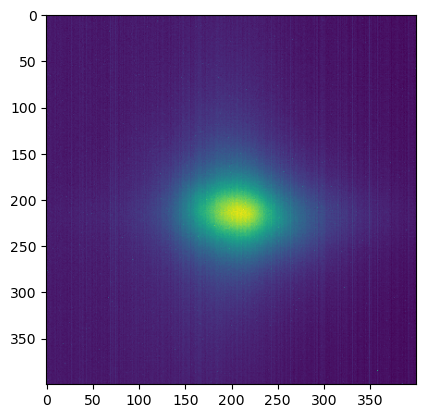

<Figure size 640x480 with 0 Axes>

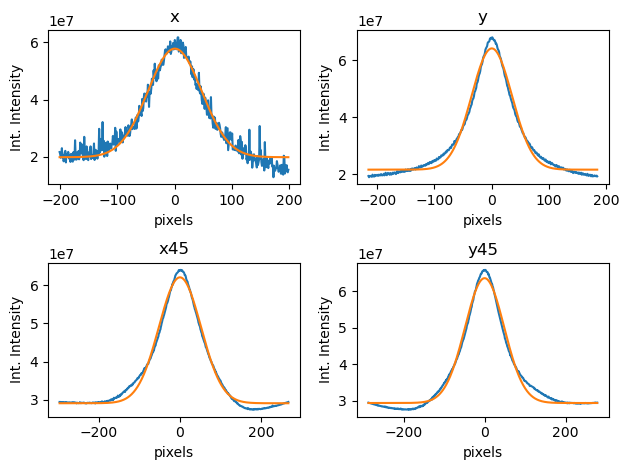

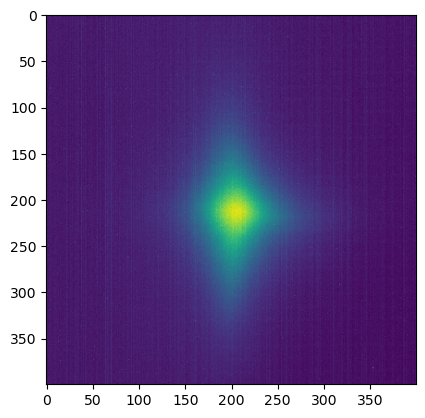

<Figure size 640x480 with 0 Axes>

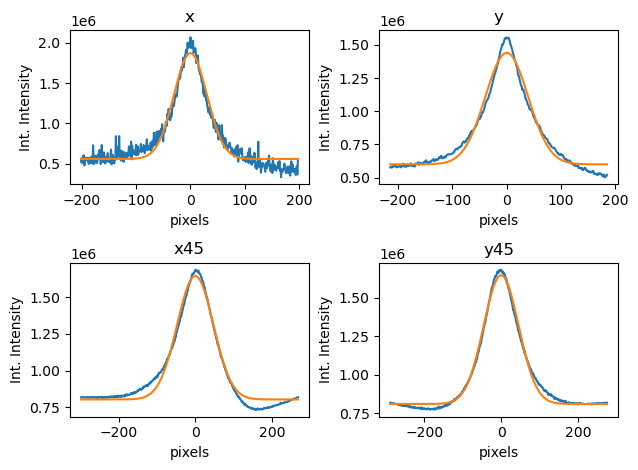

In [109]:
xcs = []
ycs = []

for i in range(len(imgArray_List)):
    img_temp = np.sum(image_stack[i],0)
    plt.figure()
    plt.imshow(img_temp)
    plt.show() 
    xfit,yfit,xfit45,yfit45 = Gaussian_Fit_4_Dim(img_temp)
    visualize_projections(img_temp)
    xcs.append(xfit.Center)
    ycs.append(yfit.Center)

In [110]:
xcs


[np.float64(200.97002863026304), np.float64(201.18918083537426)]

In [111]:
ycs

[np.float64(215.1291114788318), np.float64(214.5085524391698)]

## Make all_images

In [112]:
all_images = np.concatenate(image_stack)

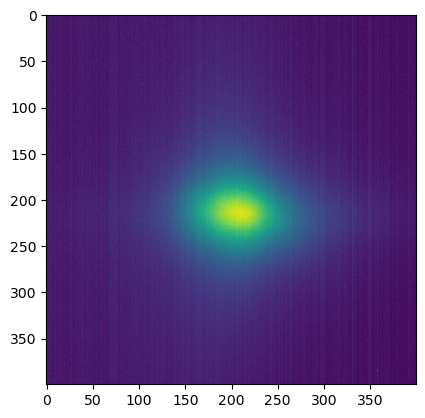

In [113]:
plt.imshow(np.sum(all_images,0))

## Make BG

In [114]:
bg_cropp = bg_img[bounds_list_new[bg_bounds]['ystart']:bounds_list_new[bg_bounds]['yend'],bounds_list_new[bg_bounds]['xstart']:bounds_list_new[bg_bounds]['xend']]

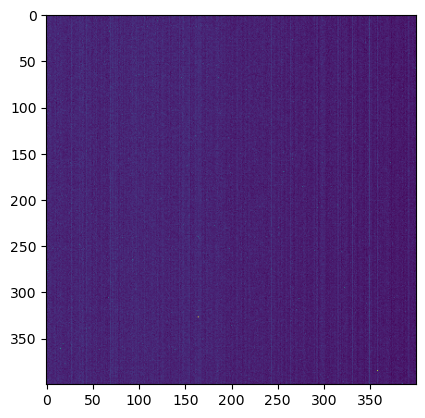

In [115]:
plt.imshow(bg_cropp)

## Make all_data

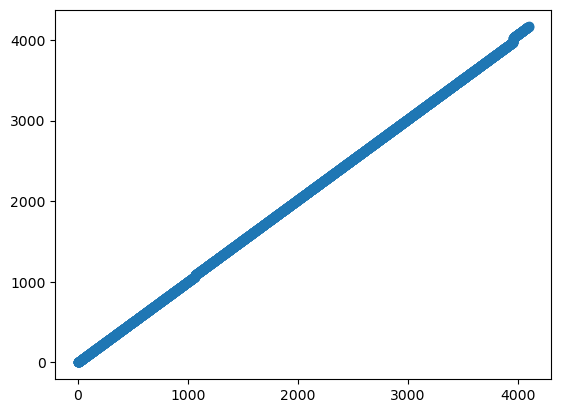

In [116]:
all_data = pd.concat(df_list)
plt.scatter(range(len(all_data)),all_data.index)

### USER INPUT: threshold to remove clipped images

In [117]:
# sums = []
# for i in range(np.shape(all_images)[0]):
#     sums.append(np.sum(all_images[i,:,:]))
# plt.plot(sums)

In [118]:
# thresh = 3.7e6

In [119]:
# rmidx = np.array(sums)<thresh
# all_images = all_images[~rmidx,:,:]



In [120]:
all_data.reset_index(drop=True,inplace=True)
# all_data = all_data[~rmidx]
# all_data.reset_index(drop=True,inplace=True)


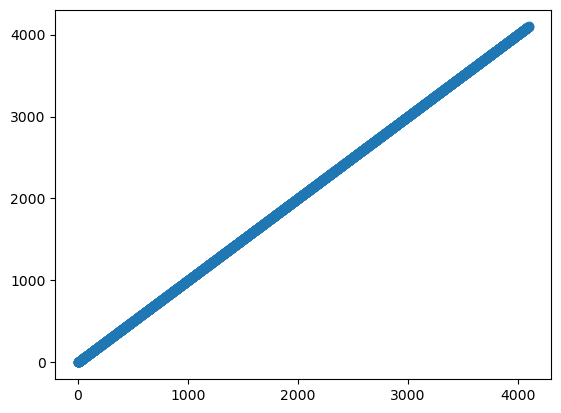

In [121]:

plt.scatter(range(len(all_data)),all_data.index)

In [122]:
len(all_data)

4099

In [123]:
np.shape(all_images)

(4099, 400, 400)

## Save

In [124]:
if screen_nickname=='241':
    rot_image_stack = np.flip(np.flip(all_images.transpose(0,2,1),axis=2),axis=1)
    rot_bg_cropp = np.flipud(np.fliplr(np.transpose(bg_cropp)))
elif screen_nickname=='571':
    rot_image_stack = np.flip(np.flip(all_images,axis=2),axis=1)
    rot_bg_cropp = np.flipud(np.fliplr(bg_cropp))
    


    


In [125]:
# np.save(save_loc + 'all_images_stack_test_' + screen_nickname + '.npy',rot_image_stack)

In [126]:
np.save(save_loc + 'total_images_stack_' + screen_nickname + '.npy',rot_image_stack)
np.save(save_loc + 'background_' + screen_nickname + '.npy',rot_bg_cropp)
all_data.to_pickle(save_loc + 'total_data_stack_' + screen_nickname + '.pkl')


In [127]:
len(rot_image_stack)

4099

<Figure size 640x480 with 0 Axes>

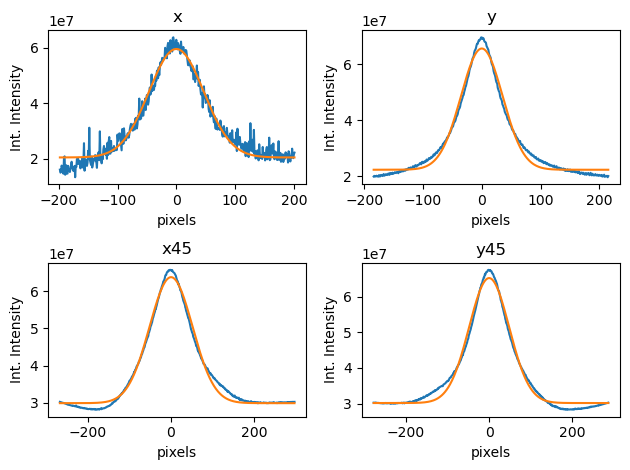

In [128]:
visualize_projections(np.sum(rot_image_stack,0))